# Edge Plasma profiles

This notebook demonstrates how to load and visualize edge plasma profiles using the `cherab.imas` interface.
Here, we propose how to visualize edge plasmas with grid meshes defined in the IMAS data structure.

The example test data was calculated by SOLPS-ITER for an ITER 15 MA H-mode scenario.

In [1]:
from typing import TYPE_CHECKING

import numpy as np
import ultraplot as uplt
from imas import DBEntry
from matplotlib.colors import SymLogNorm
from rich import print as rprint

from cherab.imas.datasets import iter_jintrac, iter_solps
from cherab.imas.ids.common import get_ids_time_slice
from cherab.imas.ids.common.ggd import load_grid
from cherab.imas.ids.edge_profiles import load_edge_species

if TYPE_CHECKING:
    from cherab.imas.ggd import UnstructGrid2D

# Set dark background for plots
uplt.rc.style = "dark_background"

## Define a function to plot edge plasma profiles

In [2]:
def plot_grid_quantity(
    ax: uplt.axes.Axes,
    grid: UnstructGrid2D,
    quantity: np.ndarray,
    title: str = "",
    title_center: str = "",
    clabel: str = "",
    logscale: bool = False,
    symmetric: bool = False,
    cbar_kwargs: dict = None,
) -> uplt.axes.Axes:
    """Plot a quantity defined on a grid."""
    ax = grid.plot_tri_mesh(data=quantity, ax=ax)

    if logscale:
        # Plot lowest values (mainly 0's) on linear map, as log(0) = -inf.
        linthresh = np.percentile(np.unique(quantity), 1)
        norm = SymLogNorm(
            linthresh=float(max(linthresh, 1.0e-10 * quantity.max())),
            base=10,
        )
        ax.collections[0].set_norm(norm)

    if symmetric:
        vmax = np.abs(quantity.max())
        ax.collections[0].set_clim(-vmax, vmax)
        ax.collections[0].set_cmap("berlin")
    else:
        ax.collections[0].set_cmap("gnuplot")

    ax.colorbar(
        ax.collections[0],
        formatter="log" if logscale else None,
        tickminor=True,
        **(cbar_kwargs or {}),
    )

    if title_center:
        ax.text(
            0.5,
            0.55,
            title_center,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=14,
        )

    ax.format(
        aspect="equal",
        xlabel="$R$ [m]",
        ylabel="$Z$ [m]",
        xlocator=1,
        ylocator=1,
        title=title,
    )
    return ax

## Retrieve the sample data

In [3]:
path = iter_solps()

Output()

## Load grid and species data

### Plot all grid subsets

In [edge_profiles IDS](https://imas-data-dictionary.readthedocs.io/en/latest/generated/ids/edge_profiles.html), there are multiple grid subsets defined.
Here, we see what grid subsets are available and plot them all.

In [4]:
# Load edge_profiles IDs
with DBEntry(path, "r") as entry:
    ids = get_ids_time_slice(
        entry,
        "edge_profiles",
        time=0,
    )

# Load grid object
grid, subsets, subset_id = load_grid(
    ids.grid_ggd[0],
    with_subsets=True,
)

# Print available grid subsets
rprint("Available grid subsets:", subset_id)

21:17:08 INFO     Parsing data dictionary version 4.1.1 @dd_zip.py:89


21:17:08 INFO     Parsing data dictionary version 4.0.0 @dd_zip.py:89


/tmp/ipykernel_3167/1326969991.py:3: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_123364_1.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  ids = get_ids_time_slice(


Available grid subsets:
{
    'Cells': 5,
    'Inner core': -1,
    'Inner SOL': -2,
    'Lower inner divertor': -3,
    'Outer core': -5,
    'Outer SOL': -6,
    'Lower outer divertor': -8,
    'Neutral pressure cells': -101,
    'CORE': 22,
    'SOL': 23,
    'OUTER_DIVERTOR': 24,
    'INNER_DIVERTOR': 25,
    'Inner Midplane': 12,
    'Outer Midplane': 11
}

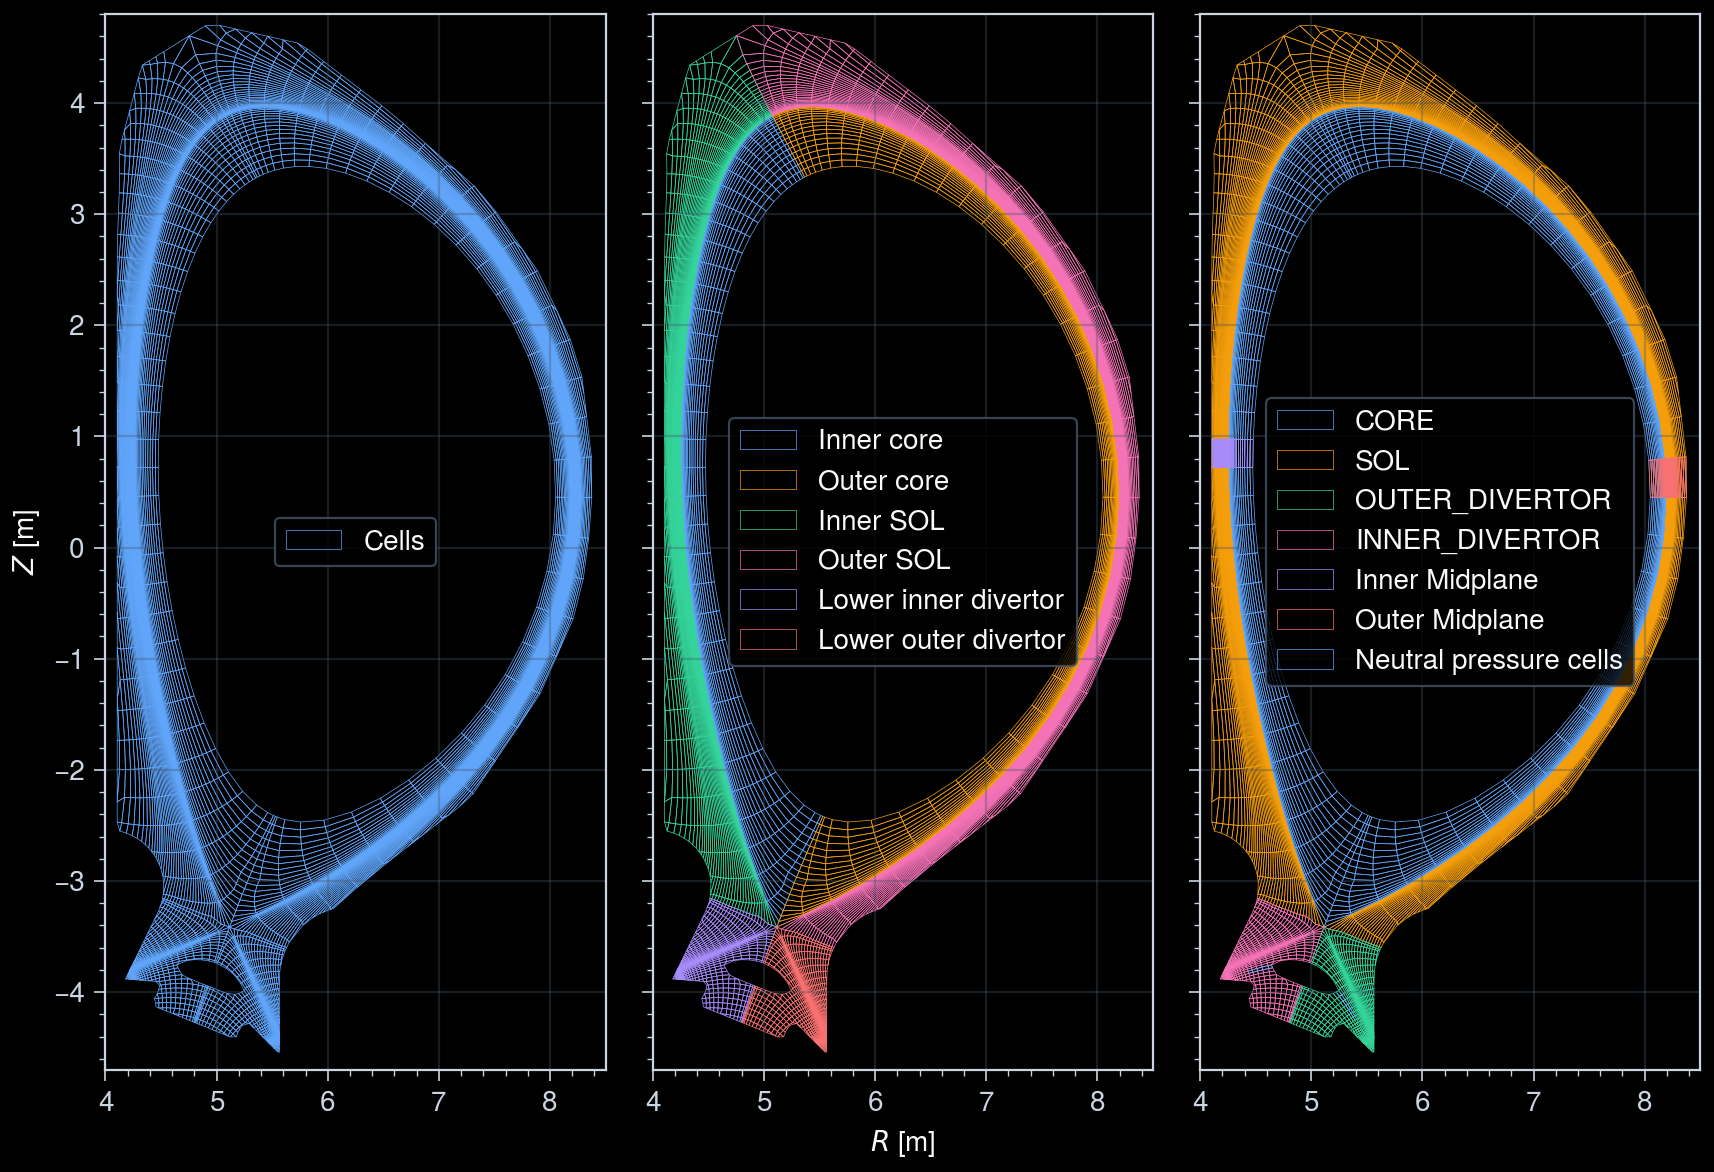

In [5]:
subset_groups = [
    [
        "Cells",
    ],
    [
        "Inner core",
        "Outer core",
        "Inner SOL",
        "Outer SOL",
        "Lower inner divertor",
        "Lower outer divertor",
    ],
    [
        "CORE",
        "SOL",
        "OUTER_DIVERTOR",
        "INNER_DIVERTOR",
        "Inner Midplane",
        "Outer Midplane",
        "Neutral pressure cells",
    ],
]

fig, axs = uplt.subplots(ncols=len(subset_groups))

for ax, subset_names in zip(axs, subset_groups, strict=True):
    for i, subset_name in enumerate(subset_names):
        grid_subset = grid.subset(subsets[subset_name])
        grid_subset.plot_mesh(ax=ax, label=subset_name, edgecolor=f"C{i}")

    ax.legend(ncols=1, loc="center")

axs.format(
    xlim=(4.0, 8.5),
    ylim=(-4.7, 4.8),
    grid=True,
    xlocator=1,
    ylocator=1,
    tickminor=True,
)

### Load edge species data

We choose the `"Cells"` subset covering the entire edge region and load the corresponding edge species data. The `edge_profiles` IDS contains multiple species, and we can choose which one to visualize.

In [6]:
grid_cells = grid.subset(subsets["Cells"])

composition = load_edge_species(
    ids.ggd[0],
    grid_subset_index=subset_id["Cells"],
    split_ion_bundles=False,
)

rprint(composition)

Warning! Using average ion temperature for the D ion (z=+1).
Warning! Using average ion temperature for the He ion (z=+1).
Warning! Using average ion temperature for the He ion (z=+2).
Warning! Using average ion temperature for the Ne ion (z=+1).
Warning! Using average ion temperature for the Ne ion (z=+2).
Warning! Using average ion temperature for the Ne ion (z=+3).
Warning! Using average ion temperature for the Ne ion (z=+4).
Warning! Using average ion temperature for the Ne ion (z=+5).
Warning! Using average ion temperature for the Ne ion (z=+6).
Warning! Using average ion temperature for the Ne ion (z=+7).
Warning! Using average ion temperature for the Ne ion (z=+8).
Warning! Using average ion temperature for the Ne ion (z=+9).
Warning! Using average ion temperature for the Ne ion (z=+10).


SpeciesComposition
├── electron
│   ├── density: shape=(6027,)
│   ├── temperature: shape=(6027,)
│   └── velocity.parallel: shape=(6027,)
├── ion (13)
│   ├── D +
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── He +
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── He 2+
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── Ne +
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── Ne 2+
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── Ne 3+
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── Ne 4+
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── Ne 5+
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── Ne 6+
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── Ne 7+
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── Ne 8+
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   ├── Ne 9+
│   │   ├── density: shape=(6027,)
│   │   ├── temperature: shape=(6027,)
│   │   └── velocity.parallel: shape=(6027,)
│   └── Ne 10+
│       ├── density: shape=(6027,)
│       ├── temperature: shape=(6027,)
│       └── velocity.parallel: shape=(6027,)
├── neutral (3)
│   ├── D
│   │   ├── density: shape=(6027,)
│   │   └── temperature: shape=(6027,)
│   ├── He
│   │   ├── density: shape=(6027,)
│   │   └── temperature: shape=(6027,)
│   └── Ne
│       ├── density: shape=(6027,)
│       └── temperature: shape=(6027,)
└── molecule (2)
    ├── D-D +
    │   ├── density: shape=(6027,)
    │   └── temperature: shape=(6027,)
    └── D-D
        ├── density: shape=(6027,)
        └── temperature: shape=(6027,)

## Plot edge plasma profiles

### Electron profiles

/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


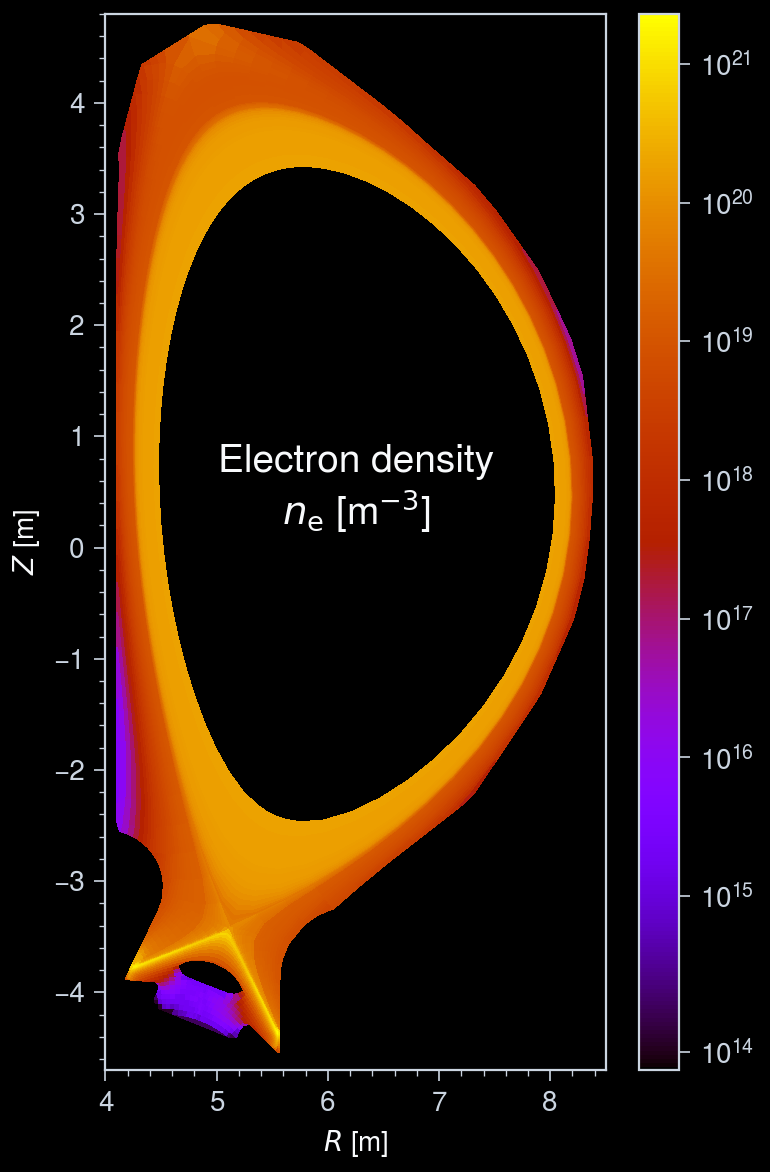

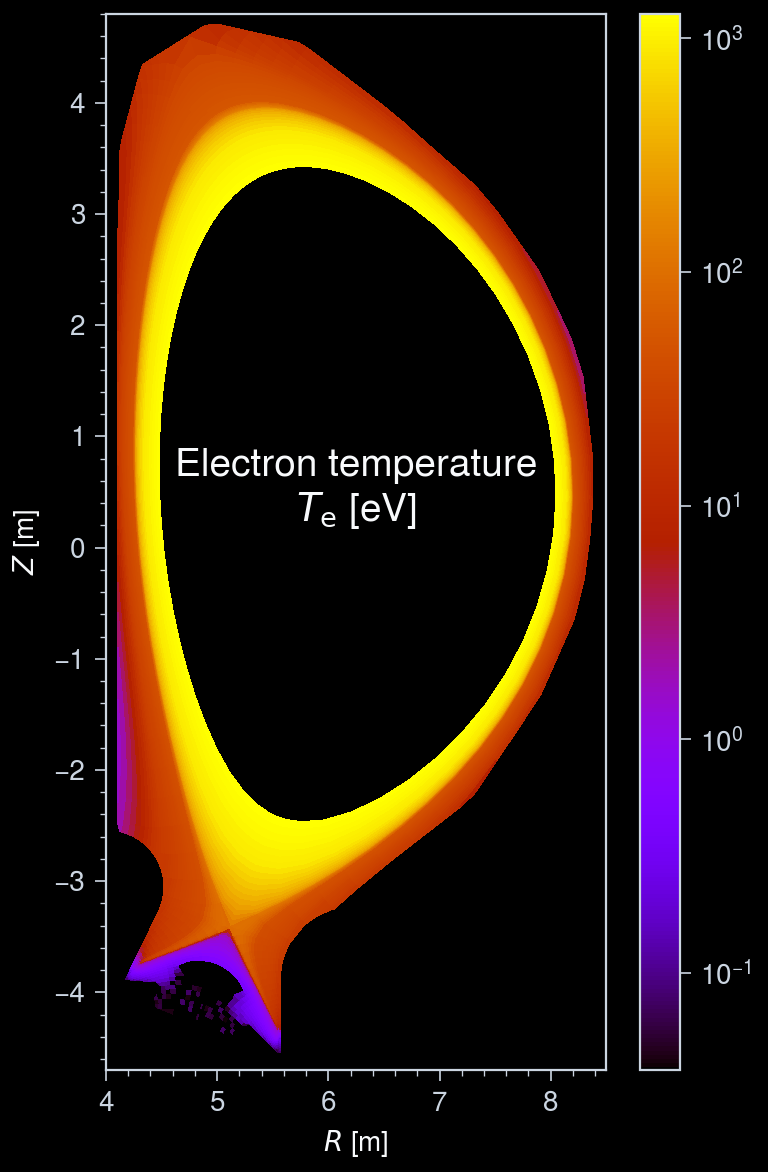

In [7]:
# Electron density
fig, ax = uplt.subplots()
ax = plot_grid_quantity(
    ax,
    grid_cells,
    composition.electron.density,
    title_center="Electron density\n$n_\\mathrm{e}$ [m$^{-3}$]",
    logscale=True,
)
ax.format(
    xlim=(4.0, 8.5),
    ylim=(-4.7, 4.8),
    xlocator=1,
    ylocator=1,
    tickminor=True,
)

# Electron temperature
fig, ax = uplt.subplots()
ax = plot_grid_quantity(
    ax,
    grid_cells,
    composition.electron.temperature,
    title_center="Electron temperature\n$T_\\mathrm{e}$ [eV]",
    logscale=True,
)
ax.format(
    xlim=(4.0, 8.5),
    ylim=(-4.7, 4.8),
    xlocator=1,
    ylocator=1,
    tickminor=True,
)

### Species profiles

/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


...

/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


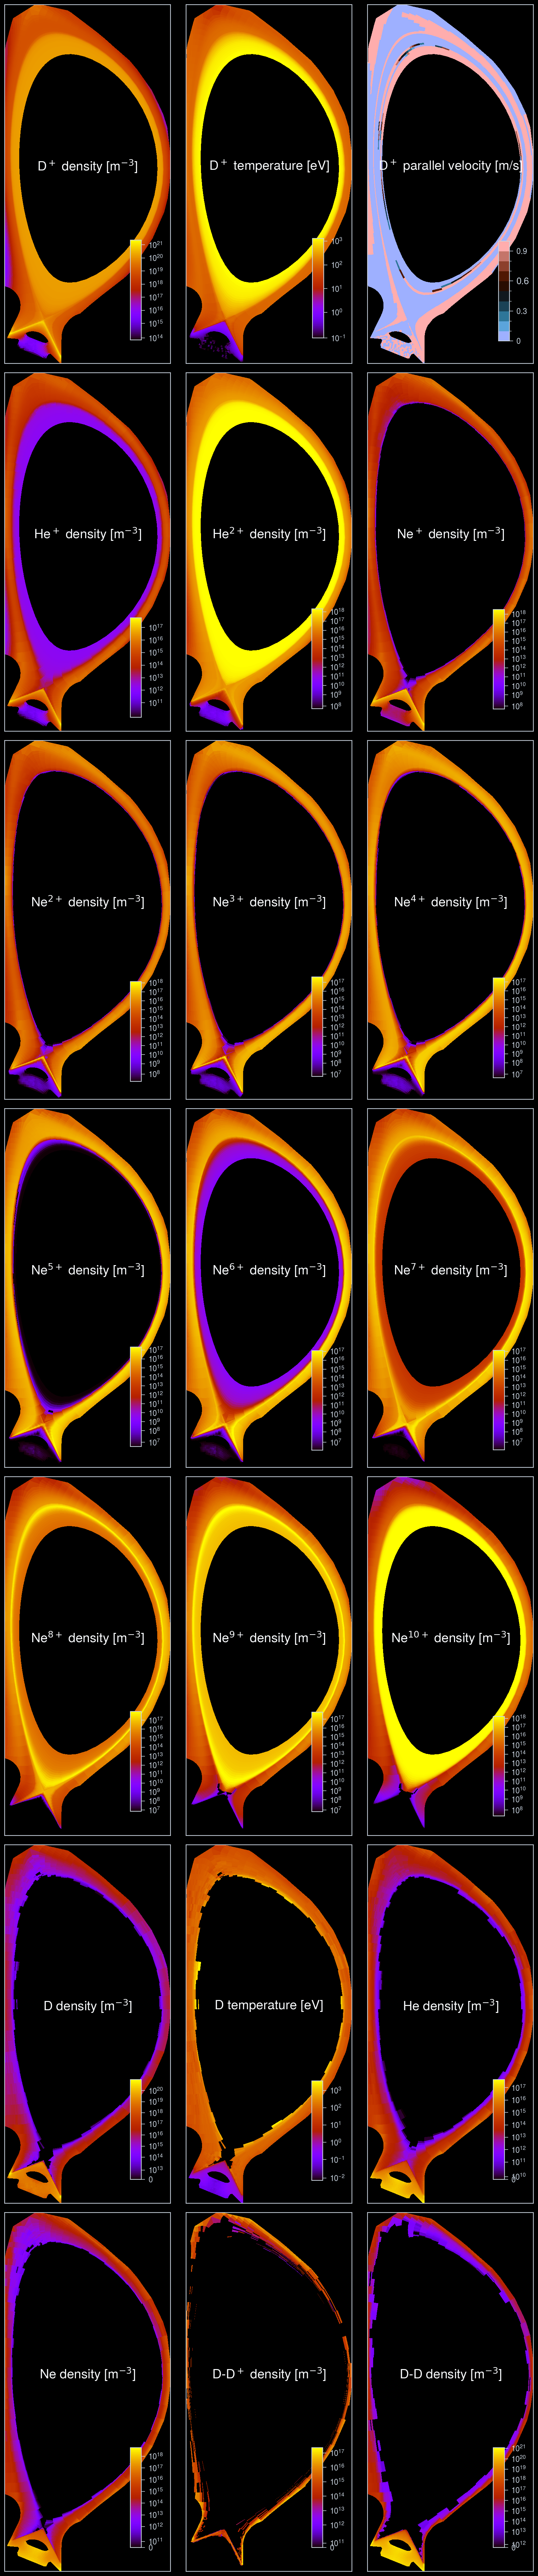

In [8]:
# Store all data to plot in a list
data: list[tuple[np.ndarray, dict]] = []

for profile in composition.ion + composition.neutral + composition.molecule:
    charge = profile.species.z_min
    if (element := profile.species.element) is not None:
        symbol = element.symbol
    elif profile.species.elements:
        symbol = "-".join(element.symbol for element in profile.species.elements)
    else:
        symbol = "Unknown"

    if charge == 0:
        name = symbol
    elif charge == 1:
        name = f"{symbol}$^+$"
    else:
        name = f"{symbol}$^{{{charge}+}}$"

    # Density
    data.append(
        (
            profile.density,
            dict(
                title_center=f"{name} density [m$^{{-3}}$]",
                logscale=True,
            ),
        )
    )
    if (element := profile.species.element) is not None and element.atomic_number == 1:
        # Temperature
        if profile.temperature is not None and np.any(profile.temperature):
            data.append(
                (
                    profile.temperature,
                    dict(
                        title_center=f"{name} temperature [eV]",
                        logscale=True,
                    ),
                )
            )
        if charge:
            # Velocity profiles
            vpar = profile.velocity.parallel
            if vpar is not None and np.any(vpar):
                data.append(
                    (
                        vpar,
                        dict(
                            title_center=f"{name} parallel velocity [m/s]",
                            symmetric=True,
                        ),
                    )
                )
        else:
            for vtype in {"radial", "poloidal", "phi"}:
                velocity = getattr(profile.velocity, vtype)
                if velocity is not None and np.any(velocity):
                    data.append(
                        (
                            velocity,
                            dict(
                                title_center=f"{name} {vtype} velocity [m/s]",
                                symmetric=True,
                            ),
                        )
                    )

# Plot all data
fig, axes = uplt.subplots(
    ncols=3,
    nrows=int(np.ceil(len(data) / 3)),
)

for i_ax, (quantity, kwargs) in enumerate(data):
    ax = plot_grid_quantity(
        axes[i_ax],
        grid_cells,
        quantity,
        **kwargs,
        cbar_kwargs=dict(
            loc="lr",
            orientation="vertical",
            ticklabelsize="small",
            length=5,
            frame=False,
        ),
    )

axes.format(
    xlabel="",
    ylabel="",
    xtickloc="neither",
    ytickloc="neither",
    linestyle="none",
    grid=False,
)

## Split the bundled species profiles

### Retrieve the bundled species profiles

In [9]:
path = iter_jintrac()

# Load edge_profiles IDs
with DBEntry(path, "r") as entry:
    ids = get_ids_time_slice(
        entry,
        "edge_profiles",
        time=0,
    )

# Load grid object
grid, subsets, subset_id = load_grid(
    ids.grid_ggd[0],
    with_subsets=True,
)

# Print available grid subsets
rprint("Available grid subsets:", subset_id)

grid_cells = grid.subset(subsets["cells"])

composition = load_edge_species(
    ids.ggd[0],
    grid_subset_index=subset_id["cells"],
    split_ion_bundles=False,
)

rprint(composition)

Warning! Unable to verify that the cell nodes are in the winding order.


/tmp/ipykernel_3167/59081011.py:5: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_53298_seq1_DD4_mod.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  ids = get_ids_time_slice(


Available grid subsets:
{'cells': 5, 'core': 22, 'sol': 23, 'inner_divertor': 25, 'outer_divertor': 24}

Warning! Using average ion temperature for the Ne ion_bundle (z=2-3).
Warning! Using average ion temperature for the Ne ion_bundle (z=4-6).
Warning! Using average ion temperature for the Ne ion_bundle (z=7-9).
Warning! Using average ion temperature for the W ion_bundle (z=2-6).
Warning! Using average ion temperature for the W ion_bundle (z=7-12).
Warning! Using average ion temperature for the W ion_bundle (z=13-22).
Warning! Using average ion temperature for the W ion_bundle (z=23-73).
Warning! Using average ion temperature for the D ion (z=+1).
Warning! Using average ion temperature for the He ion (z=+1).
Warning! Using average ion temperature for the He ion (z=+2).
Warning! Using average ion temperature for the Ne ion (z=+1).
Warning! Using average ion temperature for the Ne ion (z=+10).
Warning! Using average ion temperature for the W ion (z=+1).
Warning! Using average ion temperature for the W ion (z=+74).


SpeciesComposition
├── electron
│   ├── density: shape=(2192,)
│   ├── temperature: shape=(2192,)
│   ├── velocity.radial: shape=(2192,)
│   ├── velocity.parallel: shape=(2192,)
│   ├── velocity.poloidal: shape=(2192,)
│   └── velocity.phi: shape=(2192,)
├── ion (7)
│   ├── D +
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── He +
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── He 2+
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── Ne +
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── Ne 10+
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── W +
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   └── W 74+
│       ├── density: shape=(2192,)
│       ├── temperature: shape=(2192,)
│       ├── velocity.radial: shape=(2192,)
│       ├── velocity.parallel: shape=(2192,)
│       ├── velocity.poloidal: shape=(2192,)
│       └── velocity.phi: shape=(2192,)
├── ion_bundle (7)
│   ├── Ne 2+–3+
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── Ne 4+–6+
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── Ne 7+–9+
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── W 2+–6+
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── W 7+–12+
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   ├── W 13+–22+
│   │   ├── density: shape=(2192,)
│   │   ├── temperature: shape=(2192,)
│   │   ├── velocity.radial: shape=(2192,)
│   │   ├── velocity.parallel: shape=(2192,)
│   │   ├── velocity.poloidal: shape=(2192,)
│   │   └── velocity.phi: shape=(2192,)
│   └── W 23+–73+
│       ├── density: shape=(2192,)
│       ├── temperature: shape=(2192,)
│       ├── velocity.radial: shape=(2192,)
│       ├── velocity.parallel: shape=(2192,)
│       ├── velocity.poloidal: shape=(2192,)
│       └── velocity.phi: shape=(2192,)
├── neutral (4)
│   ├── D
│   │   ├── densi

/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)
/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/axes/plot.py:3011: UserWarning: Positional parameter c has no effect when the keyword facecolors is given
  obj = getattr(super(), name)(*args, **kwargs)


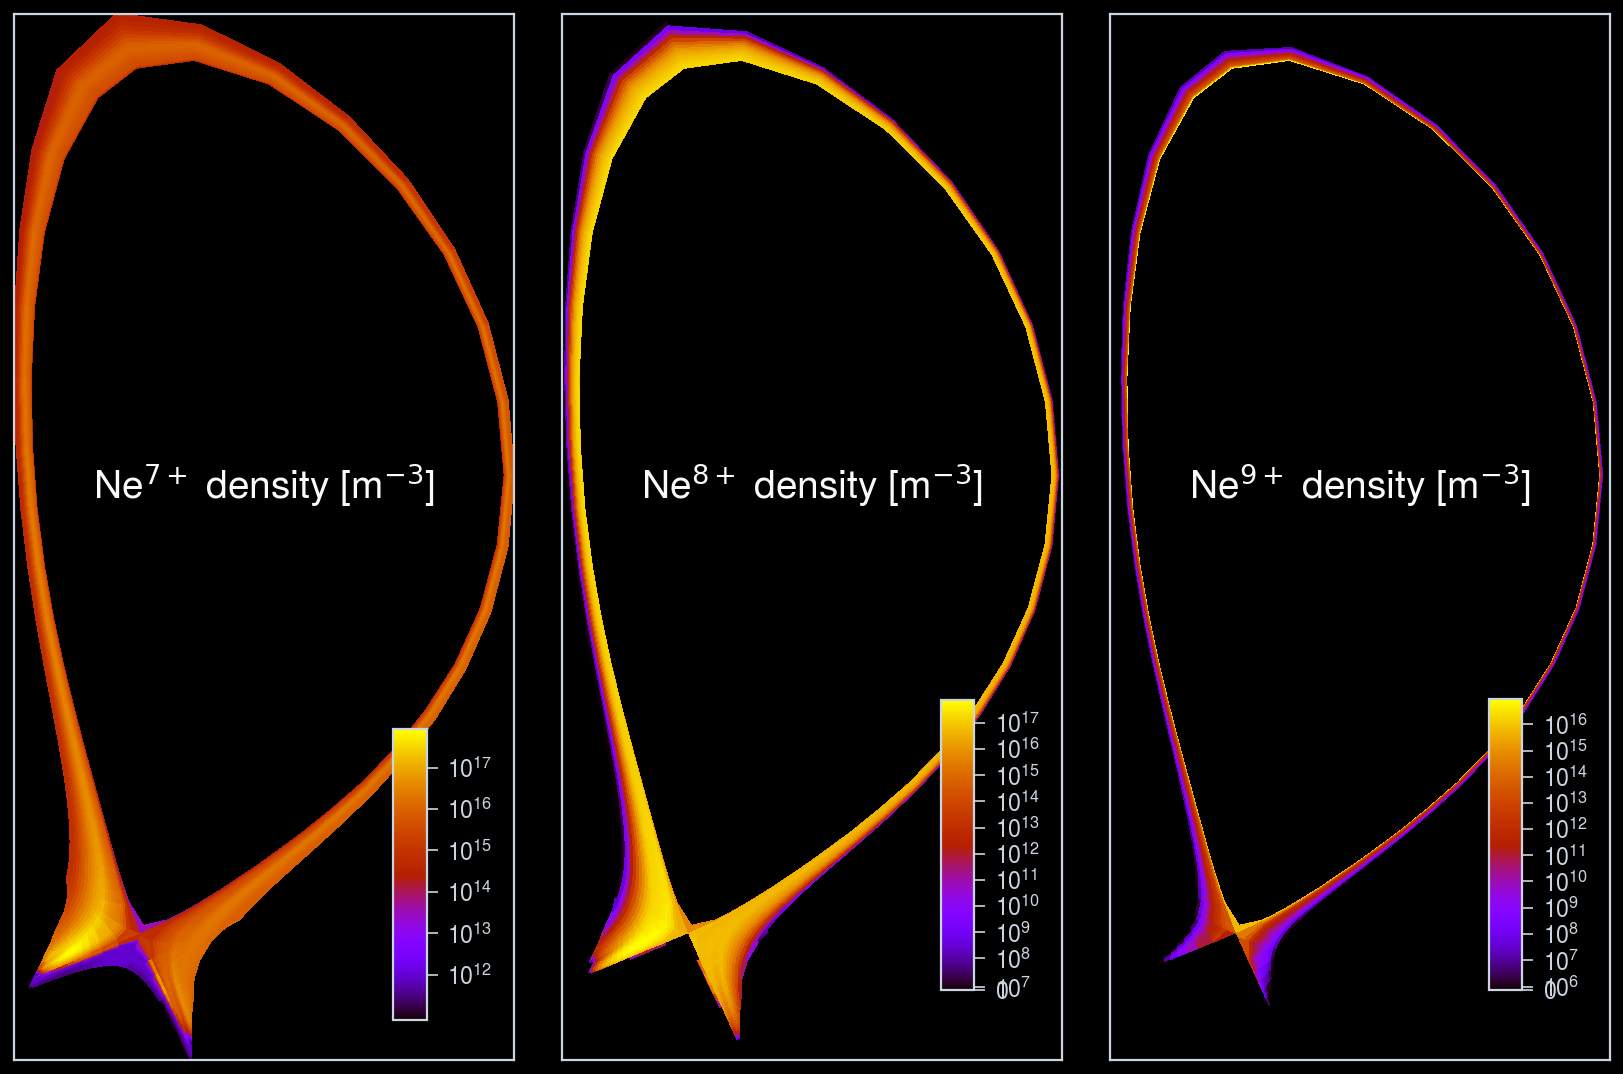

In [10]:
from cherab.core.atomic.elements import neon
from cherab.imas.ids.common import solve_coronal_equilibrium

# Select one neon ion bundle
bundle = composition.ion_bundle[2]

# Solve coronal equilibrium
densities = solve_coronal_equilibrium(
    neon,
    bundle.density,
    composition.electron.density,
    composition.electron.temperature,
    z_min=bundle.species.z_min,
    z_max=bundle.species.z_max,
)

# Plot the split charge states
fig, axes = uplt.subplots(
    ncols=3,
    nrows=int(np.ceil(densities.shape[0] / 3)),
)

for i_ax, charge in enumerate(
    np.arange(bundle.species.z_min, bundle.species.z_max + 1, dtype=int),
):
    ax = plot_grid_quantity(
        axes[i_ax],
        grid_cells,
        densities[i_ax, :],
        title_center=f"{neon.symbol}$^{{{charge}+}}$ density [m$^{{-3}}$]",
        logscale=True,
        cbar_kwargs=dict(
            loc="lr",
            orientation="vertical",
            ticklabelsize="small",
            length=5,
            frame=False,
        ),
    )

axes.format(
    xlabel="",
    ylabel="",
    xtickloc="neither",
    ytickloc="neither",
    linestyle="none",
)